# 03 · Phases 4–6 — Quality control, preprocessing, segmentation-aware trimming

Pipeline per recording (24AIM301 Unit 1):

1. read 16-bit WAV (4 kHz) → QC indicators (clipping fraction, RMS)
2. **trim** to the TSV-annotated span (label 0 = unannotated/unreliable) if ≥ 4 s remain
3. **polyphase resampling** 4 kHz → 2 kHz (built-in anti-aliasing FIR)
4. **IIR band-pass** 20–800 Hz, 4th-order Butterworth, zero-phase (`sosfiltfilt`)
5. **Schmidt spike removal** (friction / impulse artefacts)
6. **robust normalisation** (median / IQR) and clipping of residual extremes at the 99.9th percentile of |x|
7. label-free **signal descriptors** (the RL state): SNR, energy, variance, spectral centroid /
   bandwidth / flatness / entropy, ZCR, kurtosis, duration, cepstral heart rate, 32-band log-PSD

QC policy: *unreadable, silent or < 4 s* recordings are removed; *clipped or low-SNR*
recordings are only **flagged** — robustness is part of the research question.

In [1]:
%run ../common/00_config.ipynb
use_half("midsem", oracle="classical")
%run ../common/01_signal_lib.ipynb
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import Parallel, delayed

df = pd.read_csv(P["metadata"] / "circor_records.csv")
raw_dir = P["raw"]


def work(row):
    try:
        raw, fs, qc = load_wav(raw_dir / row["wav_path"])
        seg = read_tsv(raw_dir / row["tsv_path"])
        x = preprocess(raw, fs, CFG, seg)
        d = context_descriptors(x, CFG["preprocessing"]["fs"])
        d.update(qc, rms_raw=float(np.sqrt(np.mean(raw ** 2))), readable=True,
                 proc_duration_s=len(x) / CFG["preprocessing"]["fs"])
        return row["record_id"], x.astype(np.float16), d
    except Exception as e:
        return row["record_id"], None, {"readable": False, "error": repr(e)}


t0 = time.time()
res = Parallel(n_jobs=-2)(delayed(work)(r) for r in df.to_dict("records"))
print(f"processed {len(res)} recordings in {time.time() - t0:.0f}s")

Python environment is working
PyTorch: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


CirCor version 1.0.3
midsem: results -> results/midsem/ | reward oracle: classical


loaded 01_signal_lib


processed 3163 recordings in 57s


In [2]:
signals = {rid: x for rid, x, _ in res if x is not None}
desc = pd.DataFrame([{"record_id": rid, **d} for rid, _, d in res])
df = df.merge(desc, on="record_id", how="left")
q = CFG["qc"]
df["qc_clipped"] = df.clip_fraction > q["clip_fraction_max"]
df["qc_silent"] = df.rms_raw < q["silence_rms_min"]
df["qc_short"] = df.proc_duration_s < CFG["preprocessing"]["min_duration_s"]
df["qc_low_snr"] = df.snr_db < q["snr_db_min"]
df["qc_keep"] = df.readable.fillna(False).astype(bool) & ~df.qc_silent & ~df.qc_short
qc_tab = df[["readable", "qc_clipped", "qc_silent", "qc_short", "qc_low_snr", "qc_keep"]].sum().rename("count").to_frame()
qc_tab.to_csv(P["tables"] / "qc_summary.csv")
qc_tab

,count
readable,3163
qc_clipped,18
qc_silent,0
qc_short,0
qc_low_snr,0
qc_keep,3163


In [3]:
keep = set(df.record_id[df.qc_keep])
np.savez(P["segments"] / "signals.npz", **{k: v for k, v in signals.items() if k in keep})
df.to_csv(P["metadata"] / "records_qc.csv", index=False)
print("kept", len(keep), "of", len(df), "→", P["segments"] / "signals.npz")

kept 3163 of 3163 → C:\Users\roshh\Desktop\rl\version 2\data\interim\segments\signals.npz


## Example: every stage of the preprocessing chain

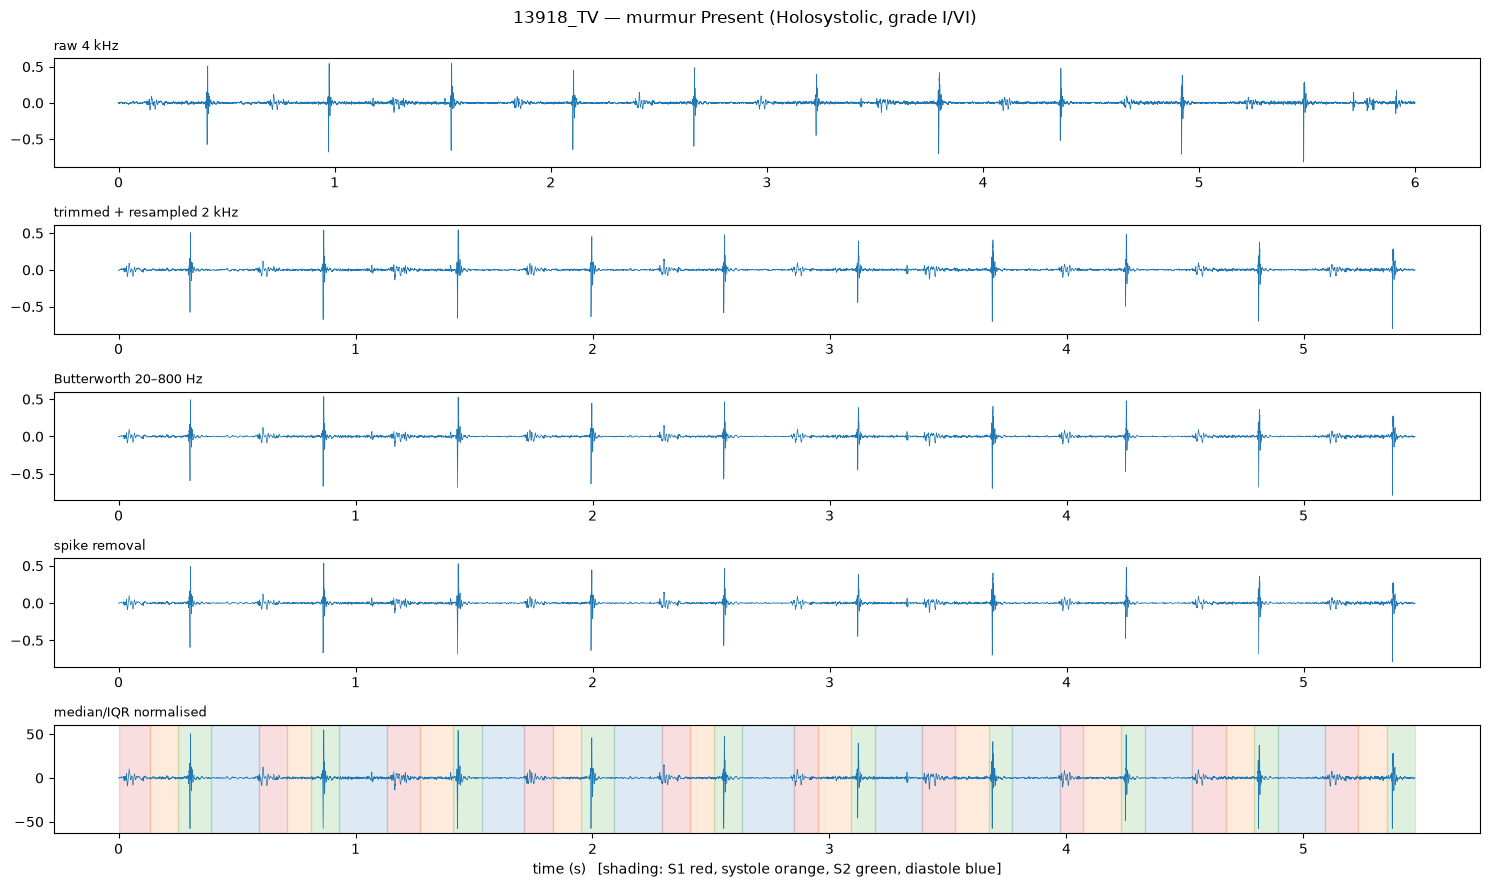

In [4]:
ex = df[(df.murmur_label == "Present") & df.qc_keep].iloc[0]
raw, fs_in, _ = load_wav(raw_dir / ex.wav_path)
seg = read_tsv(raw_dir / ex.tsv_path)
fs = CFG["preprocessing"]["fs"]
span = annotated_span(seg)
x_trim = raw[int(span[0] * fs_in): int(span[1] * fs_in)]
x_rs = sps.resample_poly(x_trim, 1, 2)
x_bp = bandpass(x_rs, 20, 800, fs)
x_sp = schmidt_spike_removal(x_bp, fs)
x_fin = clip_extremes(robust_normalize(x_sp))
stages = [("raw 4 kHz", raw, fs_in), ("trimmed + resampled 2 kHz", x_rs, fs), ("Butterworth 20–800 Hz", x_bp, fs),
          ("spike removal", x_sp, fs), ("median/IQR normalised", x_fin, fs)]
fig, ax = plt.subplots(len(stages), 1, figsize=(15, 9), sharex=False)
for a, (name, s, f) in zip(ax, stages):
    t = np.arange(len(s)) / f
    m = t < 6
    a.plot(t[m], s[m], lw=0.5)
    a.set_title(name, loc="left", fontsize=9)
colors = {1: "tab:red", 2: "tab:orange", 3: "tab:green", 4: "tab:blue"}
for s0, s1, lab in seg:
    if lab and s0 - span[0] < 6:
        ax[-1].axvspan(max(0, s0 - span[0]), s1 - span[0], color=colors[int(lab)], alpha=0.15)
ax[-1].set_xlabel("time (s)   [shading: S1 red, systole orange, S2 green, diastole blue]")
plt.suptitle(f"{ex.record_id} — murmur {ex.murmur_label} ({ex.sys_timing}, grade {ex.sys_grading})")
plt.tight_layout(); savefig(fig, "03_preprocessing_chain"); plt.show()

## QC indicators and state descriptors by class

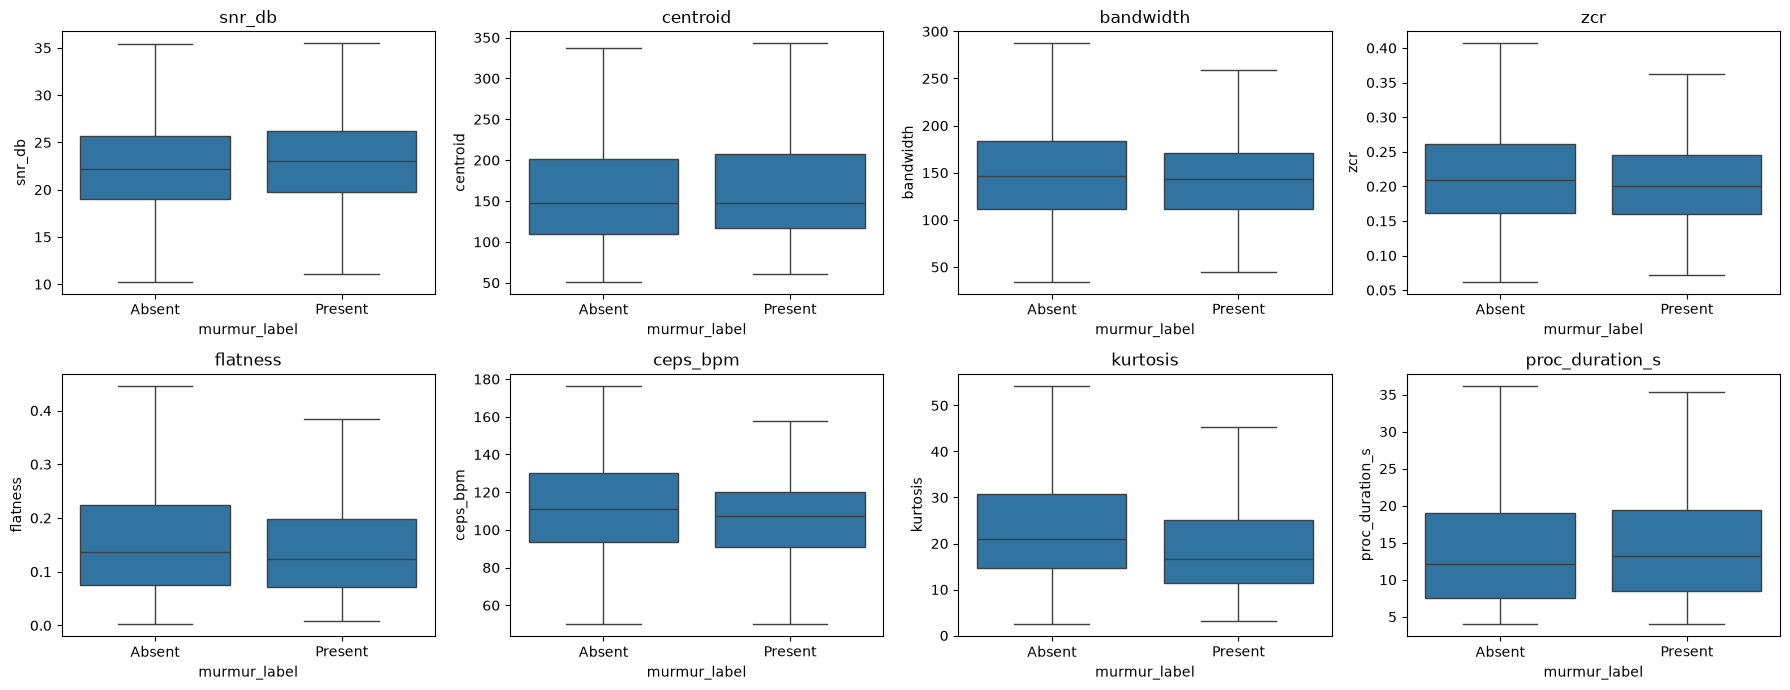

In [5]:
k = df[df.qc_keep & df.murmur_label.isin(["Present", "Absent"])]
cols = ["snr_db", "centroid", "bandwidth", "zcr", "flatness", "ceps_bpm", "kurtosis", "proc_duration_s"]
fig, ax = plt.subplots(2, 4, figsize=(18, 7))
for a, c in zip(ax.ravel(), cols):
    sns.boxplot(data=k, x="murmur_label", y=c, ax=a, showfliers=False)
    a.set_title(c)
plt.tight_layout(); savefig(fig, "03_descriptors_by_class"); plt.show()